In [1]:
import json
import os
import re
from io import StringIO
from pathlib import Path

import matplotlib as mpl
import numpy as np
import observe
import pandas as pd
from matplotlib import offsetbox as mof
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
colors = {
    "zfp.rs": mpl.cm.tab10.colors[0],
    "sz3.rs": mpl.cm.tab10.colors[6],
    "sperr.rs": mpl.cm.tab10.colors[2],
}

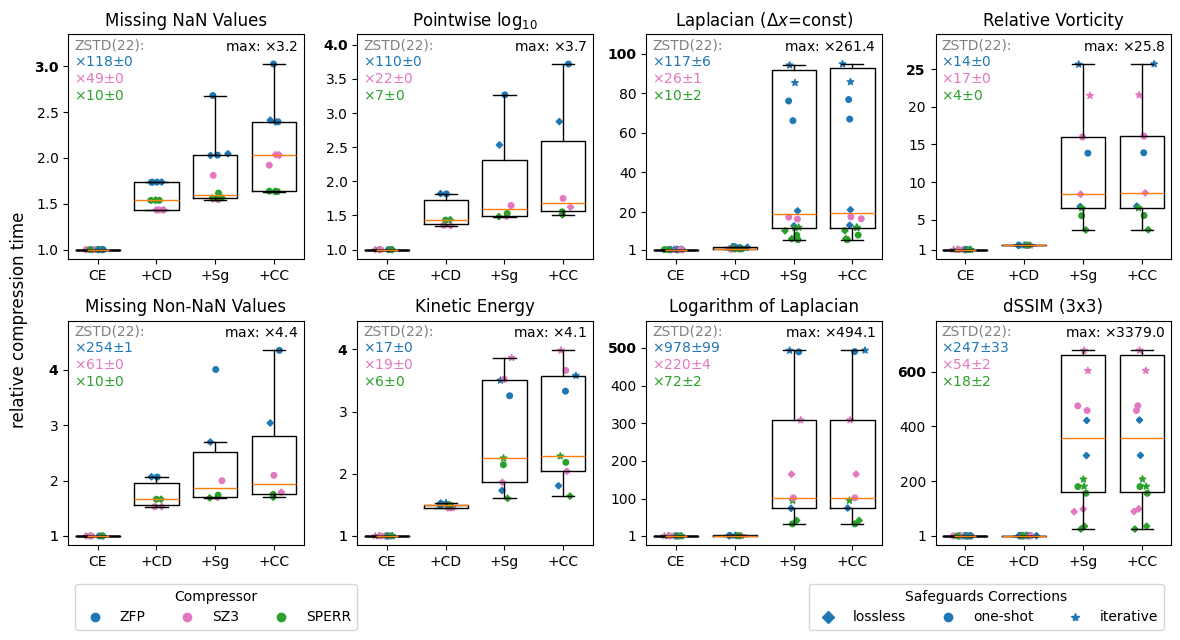

In [3]:
fig = plt.figure(layout="tight", figsize=(12, 6.5))
gs = GridSpec(3, 4, figure=fig, height_ratios=[1, 1, 0.0])

for i, (name, title) in enumerate(
    {
        "nan.json": "Missing NaN Values",
        "missing.json": "Missing Non-NaN Values",
        "specific-humidity-log10.json": r"Pointwise $\log_{10}$",
        "kinetic-energy.json": "Kinetic Energy",
        "derivative-radial.json": r"Laplacian ($\Delta x$=const)",
        "derivative-log-exp.json": "Logarithm of Laplacian",
        "vorticity.json": "Relative Vorticity",
        "dssim.json": "dSSIM (3x3)",
    }.items()
):
    with Path("observations").joinpath(name).open() as f:
        observations = json.load(f)

    scatter_colors = []
    is_iteratives = []
    is_losslesss = []
    codec_encode_timings = []
    codec_decode_timings = []
    corrections_compute_timings = []
    corrections_encode_timings = []

    zstd_encode_timing = None
    zstd_rel_encode_timings = {c: [] for c in colors.keys()}

    for result in observations:
        if result["codec"]["id"] == "zstd.rs":
            (zstd_encode_timing,) = result["encode_timing"][
                observe.json_hash(result["codec"])
            ]

        if result["codec"]["id"] != "safeguards":
            continue

        codec_id = result["codec"]["codec"]["id"]

        if codec_id == "combinators.stack":
            a, b = result["codec"]["codec"]["codecs"]
            assert a["id"] == "replace.filter", a["id"]
            codec_id = b["id"]
        elif codec_id == "pw_ratio":
            codec_id = result["codec"]["codec"]["log_codec"]["id"]

        assert codec_id in ["zero", "zfp.rs", "sz3.rs", "sperr.rs"], codec_id

        if codec_id == "zero":
            continue

        is_iterative = result["codec"]["compute"]["unstable_iterative"]
        is_lossless = result["codec"]["compute"]["unstable_lossless_corrections"]

        assert result["codec"]["lossless"]["for_codec"] is None

        (safeguarded_encode_timing,) = result["encode_timing"][
            observe.json_hash(result["codec"])
        ]
        (codec_encode_encode_timing,) = result["encode_timing"][
            observe.json_hash(result["codec"]["codec"])
        ]
        codec_encode_decode_timing, codec_decode_timing = result["decode_timing"][
            observe.json_hash(result["codec"]["codec"])
        ]
        # corrections lossless codec may be skipped if no corrections are needed
        (lossless_for_corrections_encode_timing,) = result["encode_timing"].get(
            observe.json_hash(result["codec"]["lossless"]["for_corrections"]), [None]
        )

        # skip when no corrections were needed
        # - log10 with pwe metacodec
        # - NaN with SZ3[v3.3]
        # - radial Laplacian with the 3rd error bound
        if lossless_for_corrections_encode_timing is None:
            continue

        scatter_colors.append(colors[codec_id])
        is_iteratives.append(is_iterative and not is_lossless)
        is_losslesss.append(is_iterative and is_lossless)
        codec_encode_timings.append(
            codec_encode_encode_timing / codec_encode_encode_timing
        )
        codec_decode_timings.append(
            codec_encode_decode_timing / codec_encode_encode_timing
        )
        corrections_compute_timings.append(
            lossless_for_corrections_encode_timing / codec_encode_encode_timing
        )
        corrections_encode_timings.append(
            (
                safeguarded_encode_timing
                - codec_encode_encode_timing
                - codec_encode_decode_timing
                - lossless_for_corrections_encode_timing
            )
            / codec_encode_encode_timing
        )

        zstd_rel_encode_timings[codec_id].append(
            zstd_encode_timing / codec_encode_encode_timing
        )

    is_losslesss = np.array(is_losslesss)
    is_iteratives = np.array(is_iteratives)

    ax = fig.add_subplot(gs[i % 2, i // 2])

    ax.set_title(title)

    rng = np.random.default_rng(seed=42)

    b1 = ax.boxplot(codec_encode_timings, notch=True, showfliers=False, positions=[0])
    b2 = ax.boxplot(
        np.array(codec_decode_timings) + np.array(codec_encode_timings),
        notch=False,
        showfliers=False,
        positions=[0.2],
    )
    b3 = ax.boxplot(
        np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings),
        notch=False,
        showfliers=False,
        positions=[0.4],
    )
    b4 = ax.boxplot(
        np.array(corrections_compute_timings)
        + np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings),
        notch=False,
        showfliers=False,
        positions=[0.6],
    )

    extra = (ax.get_ylim()[1] - ax.get_ylim()[0]) / 10

    ax.set_xlim(-0.1, 0.7)
    ax.set_xticklabels(["CE", "+CD", "+Sg", "+CC"])
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + extra)
    ax.set_yticks(
        [
            1 if y == 0 else y
            for y in ax.get_yticks()
            if (y >= 1 and y <= ax.get_ylim()[1]) or y == 0
        ]
    )
    ax.get_yticklabels()[-1].set_fontweight("bold")
    ax.text(
        0.68,
        b4["caps"][1].get_data()[1][0] + extra / 2,
        rf"max: $\times${np.round(np.amax(corrections_compute_timings) + np.amax(corrections_encode_timings) + np.amax(codec_decode_timings) + np.amax(codec_encode_timings), 1)}",
        ha="right",
        va="bottom",
    )

    cs = np.array(scatter_colors)

    xs = rng.normal(loc=0.0, scale=0.1 / 5, size=len(codec_encode_timings))
    ys = np.array(codec_encode_timings)
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    xs = rng.normal(loc=0.2, scale=0.1 / 5, size=len(codec_decode_timings))
    ys = np.array(codec_decode_timings) + np.array(codec_encode_timings)
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    xs = rng.normal(loc=0.4, scale=0.1 / 5, size=len(corrections_encode_timings))
    ys = (
        np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings)
    )
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    xs = rng.normal(loc=0.6, scale=0.1 / 5, size=len(corrections_compute_timings))
    ys = (
        np.array(corrections_compute_timings)
        + np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings)
    )
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    zstd_text = mof.VPacker(
        children=[
            mof.TextArea(
                "ZSTD(22):", textprops=dict(ha="left", va="center", color="gray")
            ),
        ]
        + [
            mof.TextArea(
                rf"$\times${int(np.round(np.mean(zstd_rel_encode_timings[c])))}$\pm${int(np.round(np.std(zstd_rel_encode_timings[c])))}",
                textprops=dict(ha="left", va="center", color=colors[c]),
            )
            for c in zstd_rel_encode_timings.keys()
        ],
        sep=2,
    )
    zstd_annot = mof.AnnotationBbox(
        zstd_text,
        xy=(
            -0.08,
            b4["caps"][1].get_data()[1][0] - extra * 1.7,
        ),
        box_alignment=(0, 0),
        pad=0,
        frameon=False,
    )
    ax.add_artist(zstd_annot)

fig.supylabel("relative compression time")

ax = fig.add_subplot(gs[2, :])
ax.axis("off")
l1 = ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=col,
            markeredgecolor=col,
            label={
                "zfp.rs": "ZFP",
                "sz3.rs": "SZ3",
                "sperr.rs": "SPERR",
            }[c],
        )
        for c, col in colors.items()
    ],
    ncol=3,
    loc="center left",
    title="Compressor",
)
ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            marker="D",
            color="none",
            markerfacecolor=colors["zfp.rs"],
            markeredgecolor=colors["zfp.rs"],
            label="lossless",
        ),
        mpl.lines.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=colors["zfp.rs"],
            markeredgecolor=colors["zfp.rs"],
            label="one-shot",
        ),
        mpl.lines.Line2D(
            [0],
            [0],
            marker="*",
            color="none",
            markerfacecolor=colors["zfp.rs"],
            markeredgecolor=colors["zfp.rs"],
            label="iterative",
        ),
    ],
    ncol=3,
    loc="center right",
    title="Safeguards Corrections",
)
ax.add_artist(l1)

plt.tight_layout()

plt.savefig(Path("plots") / "summary-overhead-compression.pdf", dpi=300)

plt.show()

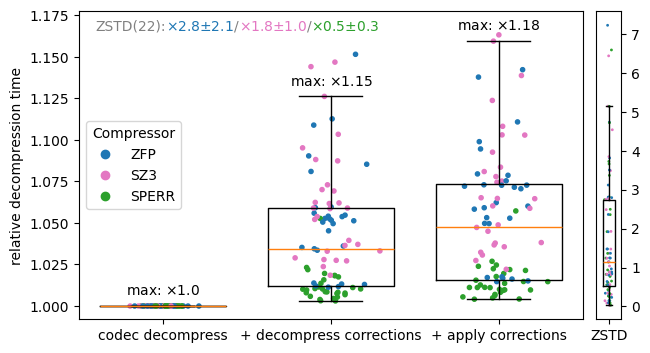

In [4]:
fig, (ax, ax2) = plt.subplots(
    1, 2, figsize=(7, 4), width_ratios=[20, 1], gridspec_kw=dict(wspace=0.05)
)

rng = np.random.default_rng(seed=42)

scatter_colors = []
codec_decode_timings = []
corrections_decode_timings = []
corrections_apply_timings = []
zstd_rel_decode_timings = {c: [] for c in colors.keys()}

for name in [
    "derivative-log-exp.json",
    "derivative-radial.json",
    "dssim.json",
    "kinetic-energy.json",
    "missing.json",
    "nan.json",
    "specific-humidity-log10.json",
    "vorticity.json",
]:
    with Path("observations").joinpath(name).open() as f:
        observations = json.load(f)

    zstd_decode_timing = None

    for result in observations:
        if result["codec"]["id"] == "zstd.rs":
            (zstd_decode_timing,) = result["decode_timing"][
                observe.json_hash(result["codec"])
            ]

        if result["codec"]["id"] != "safeguards":
            continue

        codec_id = result["codec"]["codec"]["id"]

        if codec_id == "combinators.stack":
            a, b = result["codec"]["codec"]["codecs"]
            assert a["id"] == "replace.filter", a["id"]
            codec_id = b["id"]
        elif codec_id == "pw_ratio":
            codec_id = result["codec"]["codec"]["log_codec"]["id"]

        assert codec_id in ["zero", "zfp.rs", "sz3.rs", "sperr.rs"], codec_id

        if codec_id == "zero":
            continue

        assert result["codec"]["lossless"]["for_codec"] is None

        codec_encode_decode_timing, codec_decode_timing = result["decode_timing"][
            observe.json_hash(result["codec"]["codec"])
        ]
        (safeguarded_decode_timing,) = result["decode_timing"][
            observe.json_hash(result["codec"])
        ]
        # corrections lossless codec may be skipped if no corrections are needed
        (lossless_for_corrections_decode_timing,) = result["decode_timing"].get(
            observe.json_hash(result["codec"]["lossless"]["for_corrections"]), [None]
        )

        # skip when no corrections were needed
        # - log10 with pwe metacodec
        # - NaN with SZ3[v3.3]
        # - radial Laplacian with the 3rd error bound
        if lossless_for_corrections_decode_timing is None:
            continue

        scatter_colors.append(colors[codec_id])
        codec_decode_timings.append(codec_decode_timing / codec_decode_timing)
        corrections_decode_timings.append(
            lossless_for_corrections_decode_timing / codec_decode_timing
        )
        corrections_apply_timings.append(
            (
                safeguarded_decode_timing
                - codec_decode_timing
                - lossless_for_corrections_decode_timing
            )
            / codec_decode_timing
        )

        zstd_rel_decode_timings[codec_id].append(
            zstd_decode_timing / codec_decode_timing
        )

b1 = ax.boxplot(codec_decode_timings, notch=False, showfliers=False, positions=[0])
ax.text(
    0,
    b1["caps"][1].get_data()[1][0] + 0.005,
    rf"max: $\times${np.amax(codec_decode_timings)}",
    ha="center",
    va="bottom",
)
b2 = ax.boxplot(
    np.array(corrections_decode_timings) + np.array(codec_decode_timings),
    notch=False,
    showfliers=False,
    positions=[0.2],
)
ax.text(
    0.2,
    b2["caps"][1].get_data()[1][0] + 0.005,
    rf"max: $\times${np.amax(corrections_decode_timings) + np.amax(codec_decode_timings):0.3}",
    ha="center",
    va="bottom",
)
b3 = ax.boxplot(
    np.array(corrections_apply_timings)
    + np.array(corrections_decode_timings)
    + np.array(codec_decode_timings),
    notch=False,
    showfliers=False,
    positions=[0.4],
)
ax.text(
    0.4,
    b3["caps"][1].get_data()[1][0] + 0.005,
    rf"max: $\times${np.amax(corrections_apply_timings) + np.amax(corrections_decode_timings) + np.amax(codec_decode_timings):0.3}",
    ha="center",
    va="bottom",
)

ax.set_xlim(-0.1, 0.5)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xticklabels(
    ["codec decompress", "+ decompress corrections", "+ apply corrections"]
)
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + 0.01)
ax.set_ylabel("relative decompression time")

b4 = ax2.boxplot(
    sum(zstd_rel_decode_timings.values(), start=[]),
    notch=False,
    showfliers=False,
    positions=[0.0],
)
ax2.set_xlim(-0.15, 0.15)
ax2.set_xticks([0])
ax2.set_xticklabels(["ZSTD"])
ax2.yaxis.tick_right()

ax.scatter(
    rng.normal(loc=0.0, scale=0.1 / 5, size=len(codec_decode_timings)),
    codec_decode_timings,
    marker=".",
    c=scatter_colors,
)
ax.scatter(
    rng.normal(loc=0.2, scale=0.1 / 5, size=len(corrections_decode_timings)),
    np.array(corrections_decode_timings) + np.array(codec_decode_timings),
    marker=".",
    c=scatter_colors,
)
ax.scatter(
    rng.normal(loc=0.4, scale=0.1 / 5, size=len(corrections_apply_timings)),
    np.array(corrections_apply_timings)
    + np.array(corrections_decode_timings)
    + np.array(codec_decode_timings),
    marker=".",
    c=scatter_colors,
)
ax2.scatter(
    rng.normal(
        loc=0.0,
        scale=0.1 / 5,
        size=sum(len(z) for z in zstd_rel_decode_timings.values()),
    ),
    sum(zstd_rel_decode_timings.values(), start=[]),
    marker=".",
    c=scatter_colors,
    s=4,
)

zstd_text = mof.HPacker(
    children=[
        mof.TextArea("ZSTD(22):", textprops=dict(ha="left", va="center", color="gray")),
    ]
    + [
        t
        for c in zstd_rel_encode_timings.keys()
        for t in [
            mof.TextArea(
                rf"$\times${np.round(np.mean(zstd_rel_decode_timings[c]), 1)}$\pm${np.round(np.std(zstd_rel_decode_timings[c]), 1)}",
                textprops=dict(ha="left", va="center", color=colors[c]),
            ),
            mof.TextArea("/", textprops=dict(ha="left", va="center", color="gray")),
        ]
    ][:-1]
)
zstd_annot = mof.AnnotationBbox(
    zstd_text,
    xy=(
        -0.08,
        b3["caps"][1].get_data()[1][0] + 0.007,
    ),
    box_alignment=(0, 0),
    pad=0,
    frameon=False,
)
ax.add_artist(zstd_annot)

ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=col,
            markeredgecolor=col,
            label={
                "zfp.rs": "ZFP",
                "sz3.rs": "SZ3",
                "sperr.rs": "SPERR",
            }[c],
        )
        for c, col in colors.items()
    ],
    loc="center left",
    title="Compressor",
)

# plt.tight_layout()

plt.savefig(
    Path("plots") / "summary-overhead-decompression.pdf", dpi=300, bbox_inches="tight"
)

plt.show()

In [5]:
MULTIROW_PATTERN = re.compile(r"^\\multirow\[[^\]]+\]\{(\d+)\}\{\*\}\{(.*)\}$")


def parse_latex_table(filepath: os.PathLike) -> pd.DataFrame:
    with open(filepath) as f:
        s = "".join(
            line.replace(r"\%", r"%").replace("\\\\\n", "\n")
            for line in f
            if not any(
                x in line
                for x in [
                    r"\begin{tabular}",
                    r"\toprule",
                    r"\midrule",
                    r"\cline",
                    r"\bottomrule",
                    r"\end{tabular}",
                ]
            )
        )
    pre = pd.read_table(StringIO(s), sep=r"\s*&\s*", engine="python", header=None)
    header = pre.loc[0].combine_first(pre.loc[1])
    index = list(pre.loc[1][pre.loc[1].notnull()])
    mid = pre.loc[2:].reset_index(drop=True).rename(columns=header)
    for c in index:
        i = 0
        while i < len(mid[c]):
            m = MULTIROW_PATTERN.match(str(mid[c].iloc[i]))
            if m is None:
                i += 1
            else:
                skip = int(m.group(1))
                mid.loc[i : i + skip - 1, c] = m.group(2)
                i += skip
    return mid.fillna("").set_index(index)

In [6]:
colors_with_zero = {
    "0": mpl.cm.tab10.colors[8],
    r"ZFP($\epsilon_{abs}$)": mpl.cm.tab10.colors[0],
    r"ZFP": mpl.cm.tab10.colors[0],
    r"SZ3($\epsilon_{abs}$)": mpl.cm.tab10.colors[6],
    r"SZ3[v3.2]($\epsilon_{abs}$)": mpl.cm.tab10.colors[6],
    r"SZ3": mpl.cm.tab10.colors[6],
    r"SPERR($\epsilon_{abs}$)": mpl.cm.tab10.colors[2],
    r"SPERR": mpl.cm.tab10.colors[2],
}

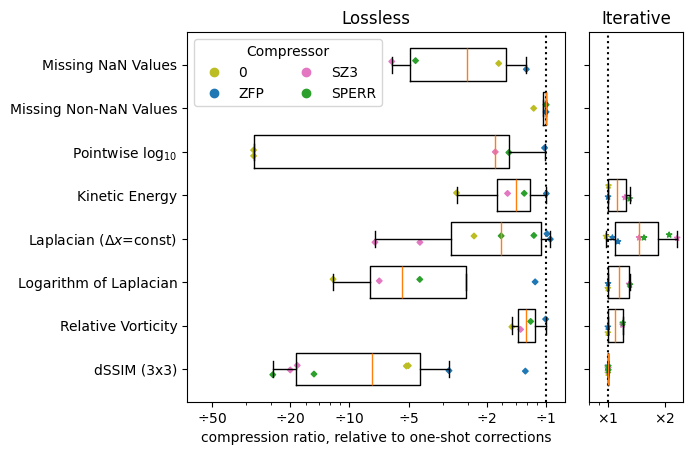

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, width_ratios=[4, 1], gridspec_kw=dict(wspace=0.1))

rng = np.random.default_rng(seed=42)

xticklabels = []

for i, (name, title) in enumerate(
    {
        "nan.tex": "Missing NaN Values",
        "missing.tex": "Missing Non-NaN Values",
        "specific-humidity-log10.tex": r"Pointwise $\log_{10}$",
        "kinetic-energy.tex": "Kinetic Energy",
        "derivative-radial.tex": r"Laplacian ($\Delta x$=const)",
        "derivative-log-exp.tex": "Logarithm of Laplacian",
        "vorticity.tex": "Relative Vorticity",
        "dssim.tex": "dSSIM (3x3)",
    }.items()
):
    crc = "CR (any NaN)" if name == "nan.tex" else "CR"

    cr = parse_latex_table(Path("tables") / name)[[crc, "C"]]

    # exclude results with no corrections
    cr = cr[cr["C"] != "0"][crc]

    cr = pd.to_numeric(cr.str.removeprefix(r"$\times$ "), errors="coerce")

    lossless = cr[cr.index.get_level_values("Corrections") == "lossless"].droplevel(
        "Corrections"
    )
    oneshot = cr[cr.index.get_level_values("Corrections") == "one-shot"].droplevel(
        "Corrections"
    )
    iterative = cr[cr.index.get_level_values("Corrections") == "iterative"].droplevel(
        "Corrections"
    )

    ax1.boxplot(
        lossless / oneshot,
        notch=False,
        showfliers=False,
        positions=[-i * 0.2],
        orientation="horizontal",
    )

    ax2.boxplot(
        iterative / oneshot,
        notch=False,
        showfliers=False,
        positions=[-i * 0.2],
        orientation="horizontal",
    )

    scatter_colors = [
        colors_with_zero[c] for c in lossless.index.get_level_values("Compressor")
    ]

    ax1.scatter(
        lossless / oneshot,
        rng.normal(loc=-i * 0.2, scale=0.1 / 5, size=len(oneshot)),
        marker="D",
        s=8,
        color=scatter_colors,
    )
    ax2.scatter(
        iterative / oneshot,
        rng.normal(loc=-i * 0.2, scale=0.1 / 5, size=len(oneshot)),
        marker="*",
        s=16,
        color=scatter_colors,
    )

    xticklabels.append(title)

ax1.set_title("Lossless")
ax1.set_xscale("log")
ax1.set_xlabel("compression ratio, relative to one-shot corrections")
ax1.set_yticks(np.arange(len(xticklabels)) * -0.2)
ax1.set_yticklabels(xticklabels)
ax1.axvline(1, c="k", zorder=-1, ls=":")
ax1.set_ylim(len(xticklabels) * -0.2 + 0.05, 0.15)
ax1.set_xlim(0.015, 1.25)
ax1.set_xticks([0.02, 0.05, 0.1, 0.2, 0.5, 1.0])
ax1.set_xticklabels(
    [r"$\div$50", r"$\div$20", r"$\div$10", r"$\div$5", r"$\div$2", r"$\div$1"]
)

ax2.set_title("Iterative")
ax2.set_xscale("log")
ax2.set_yticks(np.arange(len(xticklabels)) * -0.2)
ax2.set_yticklabels([""] * len(xticklabels))
ax2.axvline(1, c="k", zorder=-1, ls=":")
ax2.set_ylim(len(xticklabels) * -0.2 + 0.05, 0.15)
ax2.set_xlim(
    1
    / np.power(
        10.0,
        np.log10(2.5) / (1 - 4 * np.log10(1.25) / (np.log10(1.25) - np.log10(0.015)))
        - np.log10(2.5),
    ),
    2.5,
)
ax2.set_xticks([1.0, 2.0])
ax2.get_xaxis().set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, y: rf"$\times${int(x)}")
)
ax2.get_xaxis().set_minor_formatter("")

ax1.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=col,
            markeredgecolor=col,
            label=c,
        )
        for c, col in {
            "0": mpl.cm.tab10.colors[8],
            r"ZFP": mpl.cm.tab10.colors[0],
            r"SZ3": mpl.cm.tab10.colors[6],
            r"SPERR": mpl.cm.tab10.colors[2],
        }.items()
    ],
    ncol=2,
    loc="upper left",
    title="Compressor",
)

# plt.tight_layout()

plt.savefig(Path("plots") / "summary-corrections.pdf", dpi=300, bbox_inches="tight")

plt.show()

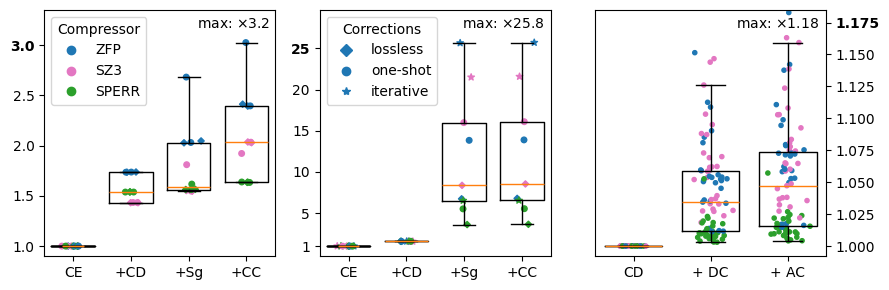

In [8]:
fig = plt.figure(layout="tight", figsize=(9, 3))
gs = GridSpec(1, 3, figure=fig)

all_scatter_colors = []
all_codec_decode_timings = []
all_corrections_decode_timings = []
all_corrections_apply_timings = []

i = 0

for name, title in {
    "nan.json": "Missing NaN Values",
    "missing.json": "Missing Non-NaN Values",
    "specific-humidity-log10.json": r"Pointwise $\log_{10}$",
    "kinetic-energy.json": "Kinetic Energy",
    "derivative-radial.json": r"Laplacian ($\Delta x$=const)",
    "derivative-log-exp.json": "Logarithm of Laplacian",
    "vorticity.json": "Relative Vorticity",
    "dssim.json": "dSSIM (3x3)",
}.items():
    with Path("observations").joinpath(name).open() as f:
        observations = json.load(f)

    scatter_colors = []
    is_iteratives = []
    is_losslesss = []
    codec_encode_timings = []
    codec_decode_timings = []
    corrections_compute_timings = []
    corrections_encode_timings = []

    for result in observations:
        if result["codec"]["id"] != "safeguards":
            continue

        codec_id = result["codec"]["codec"]["id"]

        if codec_id == "combinators.stack":
            a, b = result["codec"]["codec"]["codecs"]
            assert a["id"] == "replace.filter", a["id"]
            codec_id = b["id"]
        elif codec_id == "pw_ratio":
            codec_id = result["codec"]["codec"]["log_codec"]["id"]

        assert codec_id in ["zero", "zfp.rs", "sz3.rs", "sperr.rs"], codec_id

        if codec_id == "zero":
            continue

        is_iterative = result["codec"]["compute"]["unstable_iterative"]
        is_lossless = result["codec"]["compute"]["unstable_lossless_corrections"]

        assert result["codec"]["lossless"]["for_codec"] is None

        (safeguarded_encode_timing,) = result["encode_timing"][
            observe.json_hash(result["codec"])
        ]
        (codec_encode_encode_timing,) = result["encode_timing"][
            observe.json_hash(result["codec"]["codec"])
        ]
        codec_encode_decode_timing, codec_decode_timing = result["decode_timing"][
            observe.json_hash(result["codec"]["codec"])
        ]
        # corrections lossless codec may be skipped if no corrections are needed
        (lossless_for_corrections_encode_timing,) = result["encode_timing"].get(
            observe.json_hash(result["codec"]["lossless"]["for_corrections"]), [None]
        )

        (safeguarded_decode_timing,) = result["decode_timing"][
            observe.json_hash(result["codec"])
        ]
        # corrections lossless codec may be skipped if no corrections are needed
        (lossless_for_corrections_decode_timing,) = result["decode_timing"].get(
            observe.json_hash(result["codec"]["lossless"]["for_corrections"]), [None]
        )

        # skip when no corrections were needed
        # - log10 with pwe metacodec
        # - NaN with SZ3[v3.3]
        # - radial Laplacian with the 3rd error bound
        if lossless_for_corrections_encode_timing is None:
            continue
        assert lossless_for_corrections_decode_timing is not None

        scatter_colors.append(colors[codec_id])
        is_iteratives.append(is_iterative and not is_lossless)
        is_losslesss.append(is_iterative and is_lossless)
        codec_encode_timings.append(
            codec_encode_encode_timing / codec_encode_encode_timing
        )
        codec_decode_timings.append(
            codec_encode_decode_timing / codec_encode_encode_timing
        )
        corrections_compute_timings.append(
            lossless_for_corrections_encode_timing / codec_encode_encode_timing
        )
        corrections_encode_timings.append(
            (
                safeguarded_encode_timing
                - codec_encode_encode_timing
                - codec_encode_decode_timing
                - lossless_for_corrections_encode_timing
            )
            / codec_encode_encode_timing
        )

        all_scatter_colors.append(colors[codec_id])
        all_codec_decode_timings.append(codec_decode_timing / codec_decode_timing)
        all_corrections_decode_timings.append(
            lossless_for_corrections_decode_timing / codec_decode_timing
        )
        all_corrections_apply_timings.append(
            (
                safeguarded_decode_timing
                - codec_decode_timing
                - lossless_for_corrections_decode_timing
            )
            / codec_decode_timing
        )

    if name not in ["nan.json", "vorticity.json"]:
        continue

    is_losslesss = np.array(is_losslesss)
    is_iteratives = np.array(is_iteratives)

    ax = fig.add_subplot(gs[i])

    rng = np.random.default_rng(seed=42)

    b1 = ax.boxplot(codec_encode_timings, notch=True, showfliers=False, positions=[0])
    b2 = ax.boxplot(
        np.array(codec_decode_timings) + np.array(codec_encode_timings),
        notch=False,
        showfliers=False,
        positions=[0.2],
    )
    b3 = ax.boxplot(
        np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings),
        notch=False,
        showfliers=False,
        positions=[0.4],
    )
    b4 = ax.boxplot(
        np.array(corrections_compute_timings)
        + np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings),
        notch=False,
        showfliers=False,
        positions=[0.6],
    )

    extra = (ax.get_ylim()[1] - ax.get_ylim()[0]) / 10

    ax.set_xlim(-0.1, 0.7)
    ax.set_xticklabels(["CE", "+CD", "+Sg", "+CC"])
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + extra)
    ax.set_yticks(
        [
            1 if y == 0 else y
            for y in ax.get_yticks()
            if (y >= 1 and y <= ax.get_ylim()[1]) or y == 0
        ]
    )
    ax.get_yticklabels()[-1].set_fontweight("bold")
    ax.text(
        0.68,
        b4["caps"][1].get_data()[1][0] + extra / 2,
        rf"max: $\times${np.round(np.amax(corrections_compute_timings) + np.amax(corrections_encode_timings) + np.amax(codec_decode_timings) + np.amax(codec_encode_timings), 1)}",
        ha="right",
        va="bottom",
    )

    cs = np.array(scatter_colors)

    xs = rng.normal(loc=0.0, scale=0.1 / 5, size=len(codec_encode_timings))
    ys = np.array(codec_encode_timings)
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    xs = rng.normal(loc=0.2, scale=0.1 / 5, size=len(codec_decode_timings))
    ys = np.array(codec_decode_timings) + np.array(codec_encode_timings)
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    xs = rng.normal(loc=0.4, scale=0.1 / 5, size=len(corrections_encode_timings))
    ys = (
        np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings)
    )
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    xs = rng.normal(loc=0.6, scale=0.1 / 5, size=len(corrections_compute_timings))
    ys = (
        np.array(corrections_compute_timings)
        + np.array(corrections_encode_timings)
        + np.array(codec_decode_timings)
        + np.array(codec_encode_timings)
    )
    ax.scatter(xs[is_losslesss], ys[is_losslesss], marker="D", c=cs[is_losslesss], s=10)
    ax.scatter(
        xs[is_iteratives], ys[is_iteratives], marker="*", c=cs[is_iteratives], s=24
    )
    ax.scatter(
        xs[~(is_iteratives | is_losslesss)],
        ys[~(is_iteratives | is_losslesss)],
        marker="o",
        c=cs[~(is_iteratives | is_losslesss)],
        s=16,
    )

    if i == 0:
        ax.legend(
            handles=[
                mpl.lines.Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="none",
                    markerfacecolor=col,
                    markeredgecolor=col,
                    label={
                        "zfp.rs": "ZFP",
                        "sz3.rs": "SZ3",
                        "sperr.rs": "SPERR",
                    }[c],
                )
                for c, col in colors.items()
            ],
            loc="upper left",
            title="Compressor",
        )
    elif i == 1:
        ax.legend(
            handles=[
                mpl.lines.Line2D(
                    [0],
                    [0],
                    marker="D",
                    color="none",
                    markerfacecolor=colors["zfp.rs"],
                    markeredgecolor=colors["zfp.rs"],
                    label="lossless",
                ),
                mpl.lines.Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="none",
                    markerfacecolor=colors["zfp.rs"],
                    markeredgecolor=colors["zfp.rs"],
                    label="one-shot",
                ),
                mpl.lines.Line2D(
                    [0],
                    [0],
                    marker="*",
                    color="none",
                    markerfacecolor=colors["zfp.rs"],
                    markeredgecolor=colors["zfp.rs"],
                    label="iterative",
                ),
            ],
            loc="upper left",
            title="Corrections",
        )

    i += 1

ax = fig.add_subplot(gs[2])

b1 = ax.boxplot(all_codec_decode_timings, notch=False, showfliers=False, positions=[0])
b2 = ax.boxplot(
    np.array(all_corrections_decode_timings) + np.array(all_codec_decode_timings),
    notch=False,
    showfliers=False,
    positions=[0.2],
)
b3 = ax.boxplot(
    np.array(all_corrections_apply_timings)
    + np.array(all_corrections_decode_timings)
    + np.array(all_codec_decode_timings),
    notch=False,
    showfliers=False,
    positions=[0.4],
)

extra = (ax.get_ylim()[1] - ax.get_ylim()[0]) / 10

ax.yaxis.tick_right()

ax.set_xlim(-0.1, 0.5)
ax.set_xticks([0, 0.2, 0.4])
ax.set_xticklabels(["CD", "+ DC", "+ AC"])
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + extra)
ax.set_yticks(
    [
        1 if y == 0 else y
        for y in ax.get_yticks()
        if (y >= 1 and y <= ax.get_ylim()[1]) or y == 0
    ]
)
ax.get_yticklabels()[-1].set_fontweight("bold")

ax.text(
    0.48,
    b3["caps"][1].get_data()[1][0] + extra / 2,
    rf"max: $\times${np.amax(all_corrections_apply_timings) + np.amax(all_corrections_decode_timings) + np.amax(all_codec_decode_timings):0.3}",
    ha="right",
    va="bottom",
)

ax.scatter(
    rng.normal(loc=0.0, scale=0.1 / 5, size=len(all_codec_decode_timings)),
    all_codec_decode_timings,
    marker=".",
    c=all_scatter_colors,
)
ax.scatter(
    rng.normal(loc=0.2, scale=0.1 / 5, size=len(all_corrections_decode_timings)),
    np.array(all_corrections_decode_timings) + np.array(all_codec_decode_timings),
    marker=".",
    c=all_scatter_colors,
)
ax.scatter(
    rng.normal(loc=0.4, scale=0.1 / 5, size=len(all_corrections_apply_timings)),
    np.array(all_corrections_apply_timings)
    + np.array(all_corrections_decode_timings)
    + np.array(all_codec_decode_timings),
    marker=".",
    c=all_scatter_colors,
)

plt.tight_layout()

ax.set_rasterized(True)

plt.tight_layout()

plt.savefig(Path("plots") / "summary-overhead-egu26.pdf", dpi=300)

plt.show()